# Bayesian Marketing Mix Modeling (MMM)

**Author:** Nishant Singh  
**Framework:** PyMC v6 & ArViz

---

## Executive Summary

This notebook implements a **Bayesian Marketing Mix Model (MMM)** to evaluate marketing efficiency across seven paid media channels. The model accounts for:

1. **Adstock Carryover Effects:** Geometric decay over time (α).
2. **Baseline Dynamics:** Trend and 52-week annual seasonality using Fourier terms.
3. **Channel Effectiveness:** Non-negative media contribution coefficients (β).
4. **ROI Estimation:** Incremental revenue generated per euro spent per channel.

## 1. Setup and Data
We import the libraries and load the 104 weeks of revenue and spend for the seven channels.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from dateutil import parser

np.random.seed(42)

df = pd.read_csv("data/MMM_test_data.csv", dtype={"start_of_week": str})
spend_cols = [f"spend_channel_{i}" for i in range(1, 8)]

# All possible readings of each date (day and month may be swapped)
def candidates(s):
    out = set()
    for dayfirst in (True, False):
        try:
            out.add(parser.parse(s, dayfirst=dayfirst).date())
        except Exception:
            pass
    return out

cands = df["start_of_week"].apply(candidates)

# Complete weekly calendar: 104 Sundays from 2020-08-30
expected = pd.date_range("2020-08-30", periods=len(df), freq="7D")

# Check: is each row's expected date one of the readings found in the file?
matches = [exp.date() in c for exp, c in zip(expected, cands)]
print("Rows matching the weekly calendar:", sum(matches), "of", len(df))
print("Mismatching rows:", [i for i, m in enumerate(matches) if not m])

df["start_of_week"] = expected
print("First week:", df["start_of_week"].min().date(), "| Last week:", df["start_of_week"].max().date())
print("Gap between rows (days):")
print(df["start_of_week"].diff().dt.days.value_counts())

print(df.shape)
df.head()

Rows matching the weekly calendar: 104 of 104
Mismatching rows: []
First week: 2020-08-30 | Last week: 2022-08-21
Gap between rows (days):
start_of_week
7.0    103
Name: count, dtype: int64
(104, 9)


,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
0,2020-08-30,157906.75,2625.48,262.71,12954.12,3609.63,12955.29,12659.12,19379.79
1,2020-09-06,186425.68,2634.01,108.66,8760.28,4560.60,12747.70,12338.18,22473.45
2,2020-09-13,161607.39,2087.08,110.32,7155.42,4362.96,15015.41,10811.15,22596.05
3,2020-09-20,180089.13,1690.70,52.79,15185.22,3883.41,15521.41,12890.22,24728.73
4,2020-09-27,217793.98,1547.30,80.56,18524.05,4043.09,15793.74,12642.55,26515.48


# 2. Exploratory Data Analysis (EDA)
Before modelling, look at the data: missing values, trends, spend levels and channel correlations.

0 missing values
        revenue  spend_channel_1  spend_channel_2  spend_channel_3  \
count     104.0            104.0            104.0            104.0   
mean   136490.0           1246.0            344.0          19507.0   
std     50810.0           1388.0            333.0           8715.0   
min     63207.0              0.0              4.0           5938.0   
25%    101676.0            334.0            120.0          13879.0   
50%    128790.0            857.0            202.0          17929.0   
75%    157707.0           1658.0            553.0          22252.0   
max    418186.0           8514.0           1606.0          49689.0   

       spend_channel_4  spend_channel_5  spend_channel_6  spend_channel_7  
count            104.0            104.0            104.0            104.0  
mean            6915.0           8576.0           5064.0          27701.0  
std             3123.0           6957.0           6689.0          12176.0  
min             3602.0            747.0         

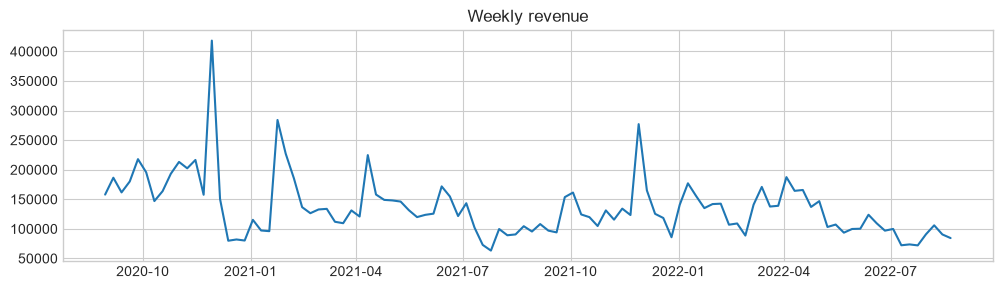

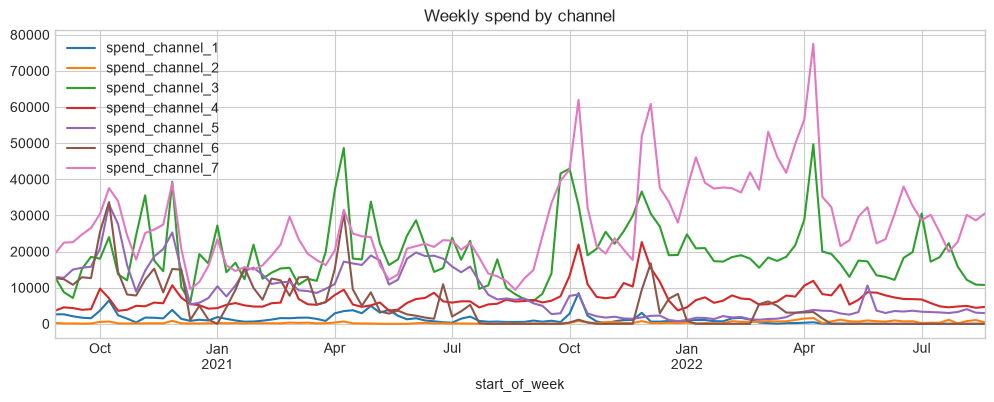

Share of total spend (%):
spend_channel_1     1.8
spend_channel_2     0.5
spend_channel_3    28.1
spend_channel_4    10.0
spend_channel_5    12.4
spend_channel_6     7.3
spend_channel_7    39.9
dtype: float64
                 spend_channel_1  spend_channel_2  spend_channel_3  \
spend_channel_1             1.00            -0.11             0.31   
spend_channel_2            -0.11             1.00             0.28   
spend_channel_3             0.31             0.28             1.00   
spend_channel_4             0.31             0.40             0.50   
spend_channel_5             0.56            -0.31             0.04   
spend_channel_6             0.51            -0.08             0.17   
spend_channel_7             0.10             0.59             0.50   

                 spend_channel_4  spend_channel_5  spend_channel_6  \
spend_channel_1             0.31             0.56             0.51   
spend_channel_2             0.40            -0.31            -0.08   
spend_channel_3     

In [14]:
print(df.isna().sum().sum(), "missing values")
print(df[["revenue"] + spend_cols].describe().round(0))

plt.figure(figsize=(12, 3))
plt.plot(df["start_of_week"], df["revenue"])
plt.title("Weekly revenue")
plt.show()

df.set_index("start_of_week")[spend_cols].plot(figsize=(12, 4), title="Weekly spend by channel")
plt.show()

print("Share of total spend (%):")
print((df[spend_cols].sum() / df[spend_cols].sum().sum() * 100).round(1))
print(df[spend_cols].corr().round(2))

### 3. Data Preparation
Revenue and spend are divided by their maximum so all values lie roughly between 0 and 1, which keeps priors simple and sampling stable. We add a trend (a time index from 0 to 1), yearly seasonality (Fourier sine and cosine waves), a Black Friday indicator for the two November revenue spikes, and, for every week, the spend of the previous 8 weeks, which is needed for the carry-over (adstock) effect.

In [16]:
T = len(df)
n_channels = len(spend_cols)

# Scale revenue and spend
y_max = df["revenue"].max()
y = (df["revenue"] / y_max).values

spend_max = df[spend_cols].max()
spend = (df[spend_cols] / spend_max).values            # shape (T, 7)

# Trend
t = np.linspace(0, 1, T)

# Yearly seasonality: 2 pairs of sine/cosine waves
year_fraction = df["start_of_week"].dt.dayofyear.values / 365.25
fourier = np.column_stack(
    [f(2 * np.pi * k * year_fraction) for k in [1, 2] for f in (np.sin, np.cos)]
)                                                       # shape (T, 4)

# Black Friday weeks (week starting the Sunday before the 4th Friday of November)
bf_weeks = []
for yr in (2020, 2021):
    fridays = pd.date_range(f"{yr}-11-01", f"{yr}-11-30", freq="W-FRI")
    bf_weeks.append(fridays[3] + pd.Timedelta(days=2))

event = df["start_of_week"].isin(bf_weeks).astype(float).values
print("Black Friday weeks flagged:", int(event.sum()))
print(df.loc[event == 1, ["start_of_week", "revenue"]])

# Lagged spend: lagged[t, c, l] = spend of channel c, l weeks before week t
L = 8
lagged = np.zeros((T, n_channels, L))
for l in range(L):
    lagged[l:, :, l] = spend[: T - l, :]
lags = np.arange(L)

print("lagged shape:", lagged.shape)

Black Friday weeks flagged: 2
   start_of_week    revenue
13    2020-11-29  418186.38
65    2021-11-28  276991.38
lagged shape: (104, 7, 8)


### 4. Model Definition
Carry-over is modelled with geometric adstock: this week's spend counts fully, last week's counts α, the week before α², and so on, with a separate α (between 0 and 1) for each channel. Revenue is a baseline (intercept, trend, seasonality, Black Friday / Cyber Monday effect) plus the adstocked spend of each channel times its effect β. Priors are weakly informative and set on the scaled data (revenue between 0 and 1): α ~ Beta(2, 4) (mean 0.33, allows both short and long effects), β ~ HalfNormal(0.1) (spend should not reduce revenue, and seven channels together should not exceed total revenue), intercept ~ Normal(0.2, 0.1), trend ~ Normal(0, 0.2), seasonality ~ Normal(0, 0.1), event effect ~ Normal(0, 0.3), and noise σ ~ HalfNormal(0.1). The priors were tightened after a first prior predictive check showed the original ones simulated revenue about five times too high.

In [20]:
coords = {"channel": spend_cols, "fourier": range(fourier.shape[1])}

with pm.Model(coords=coords) as mmm:
    # Priors
    alpha     = pm.Beta("alpha", alpha=2, beta=4, dims="channel")
    beta      = pm.HalfNormal("beta", sigma=0.1, dims="channel")
    intercept = pm.Normal("intercept", mu=0.2, sigma=0.1)
    trend_b   = pm.Normal("trend_b", mu=0, sigma=0.2)
    season_b  = pm.Normal("season_b", mu=0, sigma=0.1, dims="fourier")
    event_b   = pm.Normal("event_b", mu=0, sigma=0.3)
    sigma     = pm.HalfNormal("sigma", sigma=0.1)

    # Adstock: weights alpha^0, alpha^1, ... alpha^7 for each channel
    weights = alpha[:, None] ** lags[None, :]               # (7, L)
    adstock = (lagged * weights[None, :, :]).sum(axis=2)    # (T, 7)

    # Expected revenue
    mu = (intercept + trend_b * t + pm.math.dot(fourier, season_b) + event_b * event
          + (adstock * beta[None, :]).sum(axis=1))

    # Likelihood
    pm.Normal("revenue", mu=mu, sigma=sigma, observed=y)

mmm

### 5. Prior Predictive Check
Before using the data, we simulate revenue from the priors alone. The simulations (grey) should look plausible next to the real data (black); otherwise the priors need adjusting.

Sampling: [alpha, beta, event_b, intercept, revenue, season_b, sigma, trend_b]


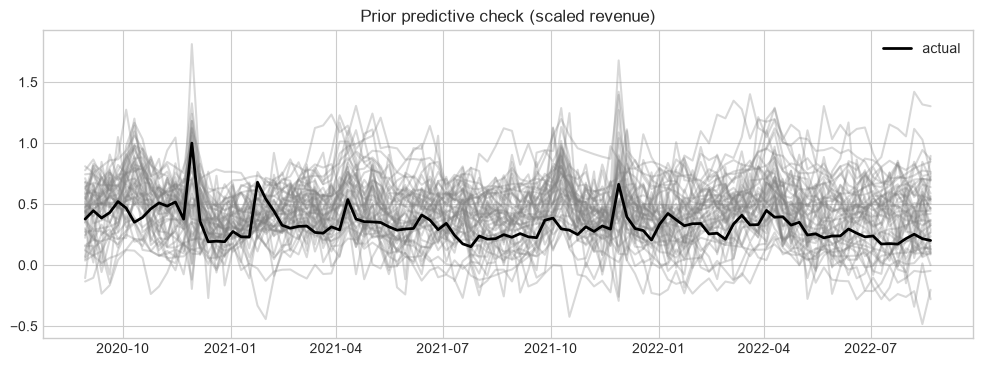

Prior simulated revenue (scaled): 5th, 50th, 95th percentile
[0.04 0.44 0.87]
Actual revenue (scaled): min, mean, max
0.15 0.33 1.0


In [21]:
with mmm:
    prior = pm.sample_prior_predictive(draws=200, random_seed=42)

prior_y = prior.prior_predictive["revenue"].stack(s=("chain", "draw")).values   # (T, 200)

plt.figure(figsize=(12, 4))
plt.plot(df["start_of_week"], prior_y[:, :50], color="grey", alpha=0.3)
plt.plot(df["start_of_week"], y, color="black", linewidth=2, label="actual")
plt.title("Prior predictive check (scaled revenue)")
plt.legend()
plt.show()

print("Prior simulated revenue (scaled): 5th, 50th, 95th percentile")
print(np.percentile(prior_y, [5, 50, 95]).round(2))
print("Actual revenue (scaled): min, mean, max")
print(y.min().round(2), y.mean().round(2), y.max().round(2))

### 6. Posterior Sampling and Diagnostics
The model now learns from the data using MCMC sampling. We check that sampling worked (r_hat below 1.01, effective sample size above 400, zero divergences) and compare prior and posterior: if they differ a lot, the data was informative about that parameter.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [alpha, beta, intercept, trend_b, season_b, event_b, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 44 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[spend_channel_1],0.311,0.176,0.066,0.63,3682,2087,1.00,0.0027,0.0027
alpha[spend_channel_2],0.329,0.178,0.078,0.65,5034,2809,1.00,0.0024,0.0026
alpha[spend_channel_3],0.271,0.154,0.064,0.55,4751,2369,1.00,0.0021,0.0025
alpha[spend_channel_4],0.281,0.16,0.065,0.58,5537,2350,1.00,0.0021,0.0025
alpha[spend_channel_5],0.258,0.14,0.062,0.51,5011,2429,1.00,0.0019,0.0022
alpha[spend_channel_6],0.292,0.159,0.073,0.57,5481,2523,1.00,0.0021,0.0026
alpha[spend_channel_7],0.316,0.164,0.081,0.6,5166,2673,1.00,0.0022,0.0023
beta[spend_channel_1],0.015,0.0146,0.00093,0.044,3611,1779,1.00,0.0002,0.00029
beta[spend_channel_2],0.0436,0.0298,0.0055,0.097,3161,2062,1.00,0.00046,0.00046
beta[spend_channel_3],0.062,0.038,0.0067,0.13,2437,1551,1.00,0.00069,0.00052


Max r_hat: 1.0032494691475777
Min ess_bulk: 2154.278375487427
Divergences: 0


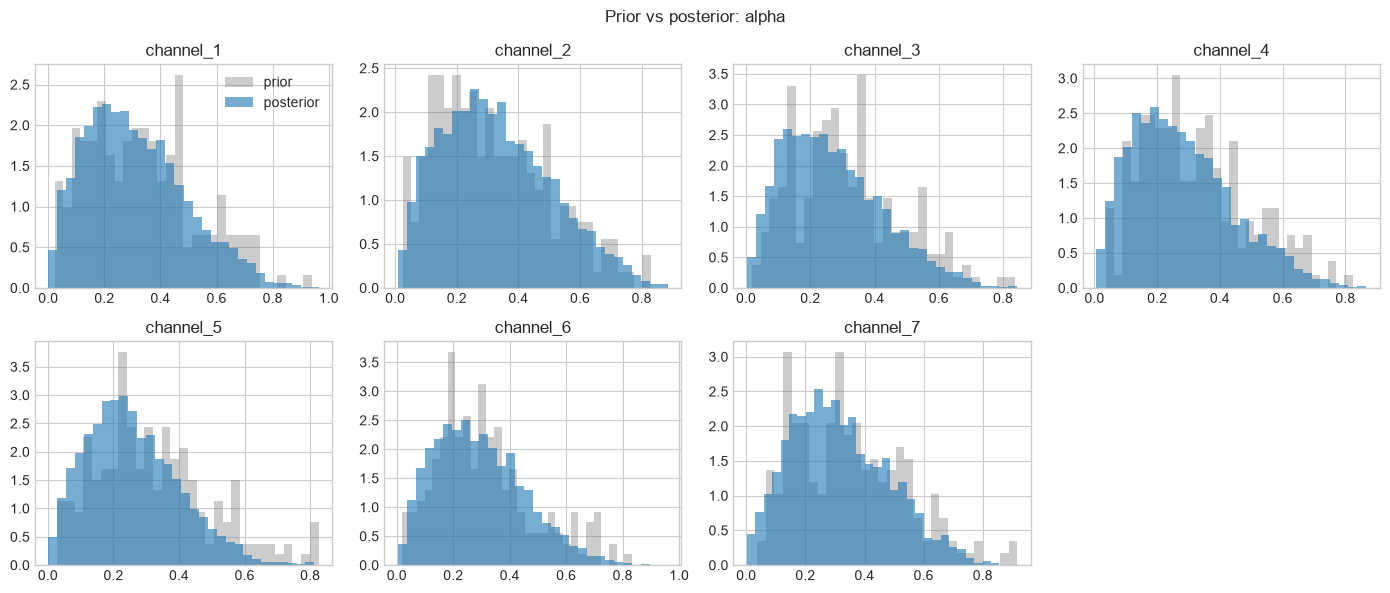

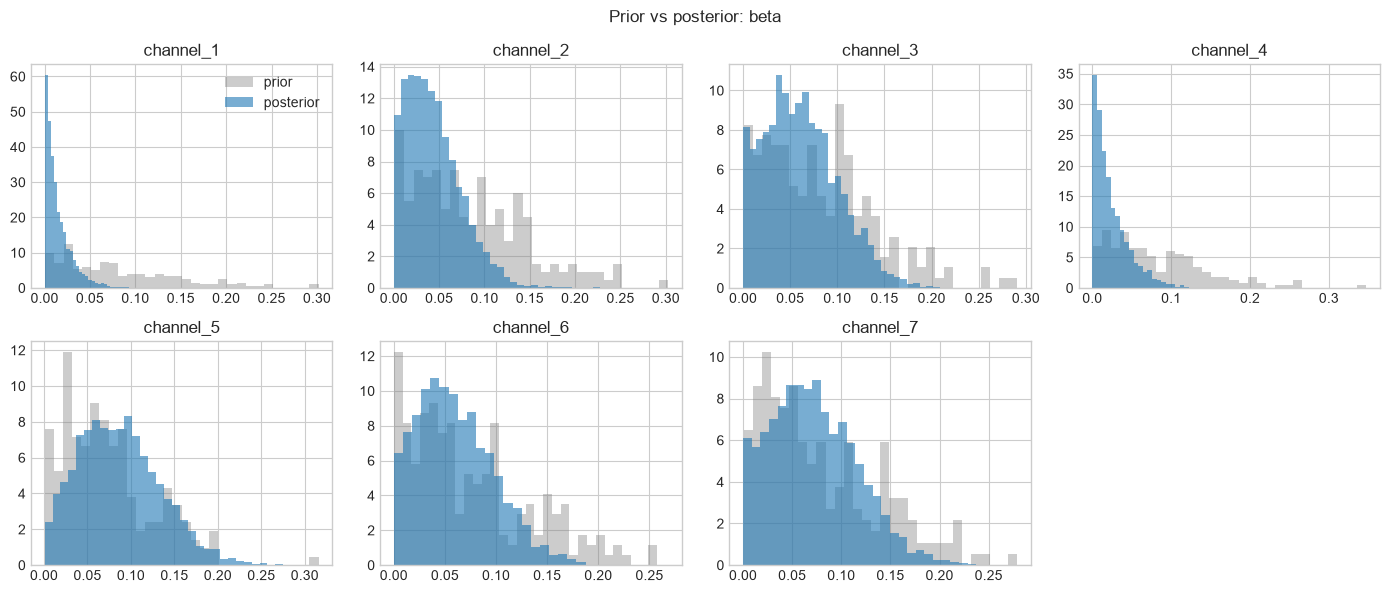

In [23]:
with mmm:
    idata = pm.sample(draws=1000, tune=1500, chains=4,
                      target_accept=0.95, random_seed=42)

summary = az.summary(idata, var_names=["alpha", "beta", "intercept", "trend_b",
                                       "season_b", "event_b", "sigma"])
display(summary.round(3))
print("Max r_hat:", summary["r_hat"].max())
print("Min ess_bulk:", summary["ess_bulk"].min())
print("Divergences:", int(idata.sample_stats["diverging"].sum()))

# Prior vs posterior for alpha and beta (one panel per channel)
for name in ["alpha", "beta"]:
    prior_vals = prior.prior[name].values.reshape(-1, n_channels)       # (draws, 7)
    post_vals  = idata.posterior[name].values.reshape(-1, n_channels)   # (draws, 7)

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    for i, ax in enumerate(axes.flat[:n_channels]):
        ax.hist(prior_vals[:, i], bins=30, density=True, alpha=0.4, color="grey", label="prior")
        ax.hist(post_vals[:, i], bins=30, density=True, alpha=0.6, color="tab:blue", label="posterior")
        ax.set_title(spend_cols[i].replace("spend_", ""))
    axes.flat[-1].axis("off")
    axes.flat[0].legend()
    fig.suptitle(f"Prior vs posterior: {name}")
    plt.tight_layout()
    plt.show()

### 7. Model Performance
We measure fit with R² (share of revenue variation explained), MAPE (average percentage error) and coverage (share of real weeks inside the model's 94% prediction interval, ideally near 94%). To test on unseen data, we refit using only the first 88 weeks and predict the last 16 weeks, which the model has never seen.

Sampling: [revenue]


Output()

In-sample  R2: 0.629 | MAPE: 17.7% | Coverage (94% interval): 97.1%


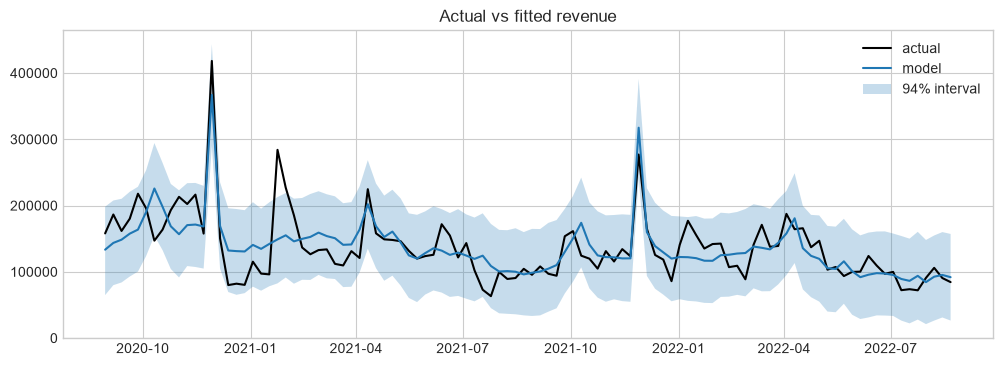

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [alpha, beta, intercept, trend_b, season_b, event_b, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 37 seconds.


Hold-out   R2: 0.063 | MAPE: 11.7%


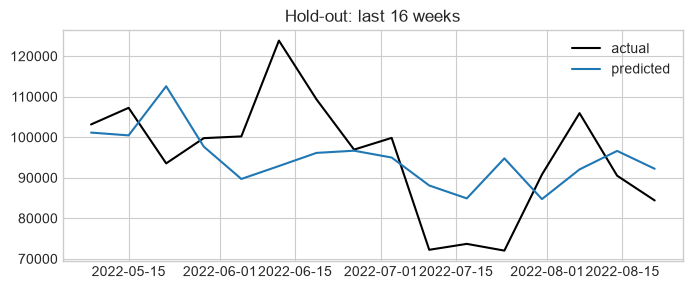

In [24]:
# ---------- In-sample fit ----------
with mmm:
    ppc = pm.sample_posterior_predictive(idata, random_seed=42)

pred = ppc.posterior_predictive["revenue"].stack(s=("chain", "draw")).values   # (T, S)
low, high = np.percentile(pred, [3, 97], axis=1)
actual = y * y_max
fitted = pred.mean(axis=1) * y_max

r2 = 1 - ((actual - fitted) ** 2).sum() / ((actual - actual.mean()) ** 2).sum()
mape = np.mean(np.abs((actual - fitted) / actual)) * 100
coverage = np.mean((y >= low) & (y <= high)) * 100
print(f"In-sample  R2: {r2:.3f} | MAPE: {mape:.1f}% | Coverage (94% interval): {coverage:.1f}%")

plt.figure(figsize=(12, 4))
plt.plot(df["start_of_week"], actual, color="black", label="actual")
plt.plot(df["start_of_week"], fitted, color="tab:blue", label="model")
plt.fill_between(df["start_of_week"], low * y_max, high * y_max, alpha=0.25, label="94% interval")
plt.legend()
plt.title("Actual vs fitted revenue")
plt.show()

# ---------- Hold-out test: train on first 88 weeks, test on the last 16 ----------
n_train = 88
train, test = slice(0, n_train), slice(n_train, T)

with pm.Model(coords=coords) as mmm_train:
    alpha     = pm.Beta("alpha", alpha=2, beta=4, dims="channel")
    beta      = pm.HalfNormal("beta", sigma=0.1, dims="channel")
    intercept = pm.Normal("intercept", mu=0.2, sigma=0.1)
    trend_b   = pm.Normal("trend_b", mu=0, sigma=0.2)
    season_b  = pm.Normal("season_b", mu=0, sigma=0.1, dims="fourier")
    event_b   = pm.Normal("event_b", mu=0, sigma=0.3)
    sigma     = pm.HalfNormal("sigma", sigma=0.1)

    weights = alpha[:, None] ** lags[None, :]
    adstock = (lagged[train] * weights[None, :, :]).sum(axis=2)
    mu = (intercept + trend_b * t[train] + pm.math.dot(fourier[train], season_b)
          + event_b * event[train]
          + (adstock * beta[None, :]).sum(axis=1))
    pm.Normal("revenue", mu=mu, sigma=sigma, observed=y[train])

    idata_train = pm.sample(draws=1000, tune=1500, chains=4,
                            target_accept=0.95, random_seed=42)

# Average (posterior mean) parameters from the training fit
def post_mean(name):
    return idata_train.posterior[name].values.mean(axis=(0, 1))

alpha_m, beta_m = post_mean("alpha"), post_mean("beta")
w = alpha_m[:, None] ** lags[None, :]
ad_test = (lagged[test] * w[None, :, :]).sum(axis=2)
pred_test = (post_mean("intercept") + post_mean("trend_b") * t[test]
             + fourier[test] @ post_mean("season_b")
             + post_mean("event_b") * event[test]
             + (ad_test * beta_m[None, :]).sum(axis=1))

actual_test = y[test] * y_max
fitted_test = pred_test * y_max
mape_test = np.mean(np.abs((actual_test - fitted_test) / actual_test)) * 100
r2_test = 1 - ((actual_test - fitted_test) ** 2).sum() / ((actual_test - actual_test.mean()) ** 2).sum()
print(f"Hold-out   R2: {r2_test:.3f} | MAPE: {mape_test:.1f}%")

plt.figure(figsize=(8, 3))
plt.plot(df["start_of_week"][test], actual_test, color="black", label="actual")
plt.plot(df["start_of_week"][test], fitted_test, color="tab:blue", label="predicted")
plt.legend()
plt.title("Hold-out: last 16 weeks")
plt.show()

### 8. Channel Insights and ROI
β shows how strongly each channel drives revenue, and α converted to a half-life shows how many weeks it takes for a channel's effect to halve. ROI is the revenue generated by a channel divided by its spend (an ROI of 2 means every unit spent returned about 2 in revenue). It is calculated for every posterior sample, so each channel gets a range instead of a single number. The channel with the highest ROI is the best performer, and the probability of being best shows how certain that conclusion is.

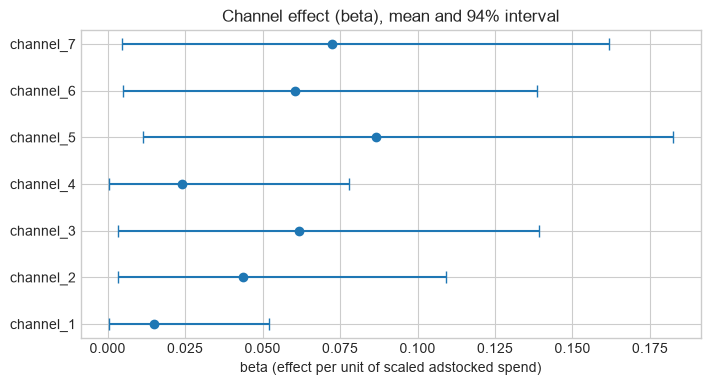

,alpha_mean,half_life_median_weeks
channel_1,0.31,0.56
channel_2,0.33,0.59
channel_3,0.27,0.50
channel_4,0.28,0.51
channel_5,0.26,0.49
channel_6,0.29,0.53
channel_7,0.32,0.57


channel_1                      1.0
channel_2                      4.5
channel_3                     10.2
channel_4                      3.1
channel_5                      9.3
channel_6                      4.0
channel_7                     12.0
baseline (everything else)    55.9
Name: % of total revenue, dtype: float64

,spend_share_%,ROI_mean,ROI_low_3%,ROI_high_97%
channel_2,0.5,17.68,1.30,45.89
channel_5,12.4,1.47,0.23,2.97
channel_1,1.8,1.11,0.04,3.79
channel_6,7.3,1.08,0.09,2.45
channel_3,28.1,0.72,0.04,1.62
channel_4,10.0,0.62,0.02,1.99
channel_7,39.9,0.59,0.04,1.38


Probability of being the best-ROI channel (%):
channel_2    94.6
channel_5     2.2
channel_1     1.4
channel_6     1.2
channel_4     0.3
channel_7     0.2
channel_3     0.1
dtype: float64


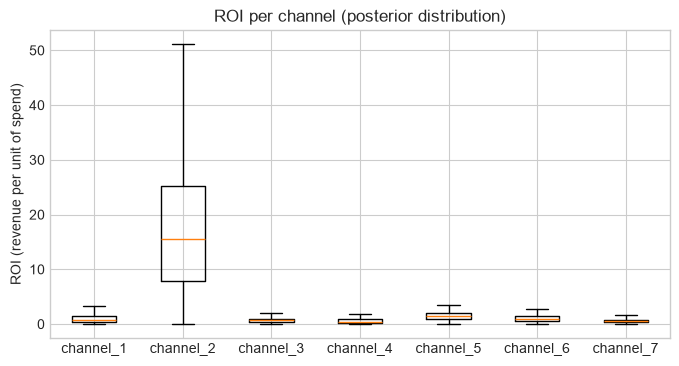

In [25]:
# ---------- Posterior samples as plain arrays ----------
alpha_s = idata.posterior["alpha"].values.reshape(-1, n_channels)   # (S, 7)
beta_s  = idata.posterior["beta"].values.reshape(-1, n_channels)    # (S, 7)
S = alpha_s.shape[0]
names = [c.replace("spend_", "") for c in spend_cols]

# ---------- Effect size (beta) ----------
beta_lo, beta_hi = np.percentile(beta_s, [3, 97], axis=0)
plt.figure(figsize=(8, 4))
plt.errorbar(beta_s.mean(axis=0), range(n_channels),
             xerr=[beta_s.mean(axis=0) - beta_lo, beta_hi - beta_s.mean(axis=0)],
             fmt="o", capsize=4)
plt.yticks(range(n_channels), names)
plt.xlabel("beta (effect per unit of scaled adstocked spend)")
plt.title("Channel effect (beta), mean and 94% interval")
plt.show()

# ---------- Carry-over: alpha and half-life ----------
half_life_s = np.log(0.5) / np.log(alpha_s)                         # weeks, per sample
carry = pd.DataFrame({
    "alpha_mean": alpha_s.mean(axis=0),
    "half_life_median_weeks": np.median(half_life_s, axis=0),
}, index=names).round(2)
display(carry)

# ---------- Contribution of each channel per posterior sample ----------
w_s = alpha_s[:, :, None] ** lags[None, None, :]                    # (S, 7, L)
adstock_s = np.einsum("tcl,scl->stc", lagged, w_s)                  # (S, T, 7)
contrib = adstock_s * beta_s[:, None, :] * y_max                    # revenue units
total_contrib = contrib.sum(axis=1)                                 # (S, 7)

# ---------- Share of total revenue ----------
total_revenue = df["revenue"].sum()
share = total_contrib.mean(axis=0) / total_revenue * 100
breakdown = pd.Series(share.round(1), index=names, name="% of total revenue")
breakdown["baseline (everything else)"] = round(100 - share.sum(), 1)
display(breakdown)

# ---------- ROI = contribution / spend ----------
total_spend = df[spend_cols].sum().values
roi_s = total_contrib / total_spend[None, :]                        # (S, 7)

roi = pd.DataFrame({
    "spend_share_%": (total_spend / total_spend.sum() * 100).round(1),
    "ROI_mean": roi_s.mean(axis=0),
    "ROI_low_3%": np.percentile(roi_s, 3, axis=0),
    "ROI_high_97%": np.percentile(roi_s, 97, axis=0),
}, index=names).round(2).sort_values("ROI_mean", ascending=False)
display(roi)

# ---------- Probability that each channel has the best ROI ----------
best = np.argmax(roi_s, axis=1)
prob_best = pd.Series(np.bincount(best, minlength=n_channels) / S * 100,
                      index=names).round(1).sort_values(ascending=False)
print("Probability of being the best-ROI channel (%):")
print(prob_best)

# ---------- ROI chart ----------
plt.figure(figsize=(8, 4))
plt.boxplot(roi_s, showfliers=False)
plt.xticks(range(1, n_channels + 1), names)
plt.ylabel("ROI (revenue per unit of spend)")
plt.title("ROI per channel (posterior distribution)")
plt.show()

### 9. Sensitivity Check: Prior on ROI
In the main model all channels share the same prior on β, which implicitly gives small-spend channels a much higher prior ROI. As a robustness check we refit the model with the prior placed directly on ROI (HalfNormal(1.5), mean about 1.2, identical for all channels), with β derived from ROI and each channel's total adstocked spend. Everything else is unchanged. If the channel ranking holds under this fairer prior, the conclusions do not depend on the prior choice.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [alpha, roi, intercept, trend_b, season_b, event_b, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 40 seconds.


Max r_hat: 1.0028743398529063 | Min ess_bulk: 1824.6096278547036 | Divergences: 0


,spend_share_%,ROI_original,ROI_roi_prior,low_3%,high_97%
channel_5,12.4,1.47,1.34,0.11,2.88
channel_2,0.5,17.68,1.22,0.07,3.29
channel_6,7.3,1.08,1.14,0.12,2.42
channel_7,39.9,0.59,0.82,0.12,1.63
channel_1,1.8,1.11,0.71,0.03,2.22
channel_3,28.1,0.72,0.71,0.04,1.63
channel_4,10.0,0.62,0.52,0.02,1.66


Probability of being the best-ROI channel (%), ROI-prior model:
channel_5    32.9
channel_2    25.6
channel_6    21.8
channel_1     8.0
channel_7     5.8
channel_3     3.4
channel_4     2.6
dtype: float64


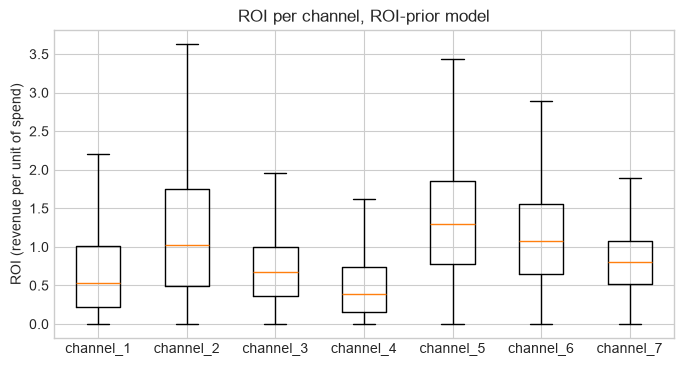

In [26]:
total_spend = df[spend_cols].sum().values          # original spend units

with pm.Model(coords=coords) as mmm_roi:
    # Priors
    alpha     = pm.Beta("alpha", alpha=2, beta=4, dims="channel")
    roi       = pm.HalfNormal("roi", sigma=1.5, dims="channel")     # same prior for every channel
    intercept = pm.Normal("intercept", mu=0.2, sigma=0.1)
    trend_b   = pm.Normal("trend_b", mu=0, sigma=0.2)
    season_b  = pm.Normal("season_b", mu=0, sigma=0.1, dims="fourier")
    event_b   = pm.Normal("event_b", mu=0, sigma=0.3)
    sigma     = pm.HalfNormal("sigma", sigma=0.1)

    # Adstock
    weights = alpha[:, None] ** lags[None, :]
    adstock = (lagged * weights[None, :, :]).sum(axis=2)            # (T, 7)

    # beta derived from ROI: contribution = roi * total spend
    beta = roi * total_spend / (y_max * adstock.sum(axis=0))

    mu = (intercept + trend_b * t + pm.math.dot(fourier, season_b) + event_b * event
          + (adstock * beta[None, :]).sum(axis=1))
    pm.Normal("revenue", mu=mu, sigma=sigma, observed=y)

    idata_roi = pm.sample(draws=1000, tune=1500, chains=4,
                          target_accept=0.95, random_seed=42, progressbar=False)

# Diagnostics
s = az.summary(idata_roi, var_names=["roi", "alpha", "intercept", "trend_b", "event_b", "sigma"])
print("Max r_hat:", s["r_hat"].max(), "| Min ess_bulk:", s["ess_bulk"].min(),
      "| Divergences:", int(idata_roi.sample_stats["diverging"].sum()))

# ROI comparison: original model vs ROI-prior model
roi_new = idata_roi.posterior["roi"].values.reshape(-1, n_channels)
cmp = pd.DataFrame({
    "spend_share_%": (total_spend / total_spend.sum() * 100).round(1),
    "ROI_original": roi_s.mean(axis=0),
    "ROI_roi_prior": roi_new.mean(axis=0),
    "low_3%": np.percentile(roi_new, 3, axis=0),
    "high_97%": np.percentile(roi_new, 97, axis=0),
}, index=names).round(2).sort_values("ROI_roi_prior", ascending=False)
display(cmp)

best_new = np.argmax(roi_new, axis=1)
prob_best_new = pd.Series(np.bincount(best_new, minlength=n_channels) / len(best_new) * 100,
                          index=names).round(1).sort_values(ascending=False)
print("Probability of being the best-ROI channel (%), ROI-prior model:")
print(prob_best_new)

plt.figure(figsize=(8, 4))
plt.boxplot(roi_new, showfliers=False)
plt.xticks(range(1, n_channels + 1), names)
plt.ylabel("ROI (revenue per unit of spend)")
plt.title("ROI per channel, ROI-prior model")
plt.show()

### 10. Conclusions and Limitations

**Carry-over.** Spend carry-over is modelled with geometric adstock over an 8-week window, with a separate decay rate α per channel (prior Beta(2, 4)). The posterior α values (0.26 to 0.33, half-life about 0.5 weeks) stay close to the prior, so the data cannot say how long each channel's effect lasts. Most of the effect lands in the same week, and the channel-specific differences should not be over-interpreted.

**Priors and sampling.** All priors are weakly informative and were set on scaled data (revenue and spend divided by their maximum). A first prior predictive check showed simulated revenue about five times too high, so the β, intercept and seasonality priors were tightened; the second check covered the real revenue range (simulated 5th to 95th percentile 0.04 to 0.87 against actual 0.15 to 1.0). Posterior sampling converged cleanly (max r_hat 1.003, minimum effective sample size above 2,100, no divergences). The posterior moved clearly for the baseline, the Black Friday / Cyber Monday effect and the channel effects β, but hardly at all for α.

**Model performance.** The model explains 63% of weekly revenue variation in-sample (R² 0.629, MAPE 17.7%), and its 94% prediction interval covers 97% of weeks. On the last 16 weeks, held out from training, MAPE is 11.7% (R² 0.06, low because those weeks are flat with little variation to explain). The model captures the downward trend and both November peaks, but misses one-off spikes such as late January 2021 that no spend channel can explain.

**Revenue drivers.** Paid media explains about 44% of revenue and the baseline (intercept, trend, Black Friday / Cyber Monday and seasonality) about 56%. By revenue share, channels 7 (12.0%), 3 (10.2%) and 5 (9.3%) contribute most. Blended ROI across all media is about 0.87 revenue per unit of spend.

**ROI and best channel.** ROI is each channel's modelled revenue divided by its spend. With the same prior β for all channels, channel 2 looked extremely strong (ROI 17.7), but this was an artefact of its tiny spend (0.5% of budget). Placing the prior directly on ROI removed the effect: channel 5 leads (ROI 1.34, 94% interval 0.11 to 2.88), followed by channels 2 (1.22) and 6 (1.14), while channels 3, 1 and 4 are lowest (0.71, 0.71, 0.52) and channel 7, which takes 40% of spend, is at 0.82. Intervals overlap heavily, so channel 5 is the best-supported choice (about 33% probability of being best) but not a certain winner. Paid media overall is close to break-even on revenue, and the evidence modestly favours shifting budget from channels 3, 4 and 7 towards channels 5 and 6.

**Limitations.** There is no saturation (diminishing returns), so ROI is an average and not a marginal ROI. The channels are partly correlated (up to 0.65), and with only 104 weeks the effects are not sharply separated. Revenue spikes without matching spend are unexplained. ROI is revenue, not profit, and the results show association rather than proven causation. Incrementality tests would be the best way to calibrate the channel effects, and a saturation curve and time-varying effects are natural next steps.